Curve sample:
2010-01-04 00:00:00 -> 2026-03-05 00:00:00
        date      z252       z504      z1260  z2520   fwd_1y1y   fwd_5y5y  \
0 2010-01-04  9.742216  11.150895  12.494929  13.07  12.577656  13.648011   
1 2010-01-05  9.754283  11.134502  12.507585  13.08  12.532078  13.655328   
2 2010-01-06  9.711983  11.083377  12.479870  13.09  12.471913  13.703439   
3 2010-01-07  9.703655  11.072326  12.527588  13.13  12.458073  13.735637   
4 2010-01-08  9.674293  11.062328  12.510103  13.08  12.467929  13.652784   

   spread_5y5y_minus_1y1y  
0                1.070356  
1                1.123250  
2                1.231526  
3                1.277564  
4                1.184855  

IPCA monthly:
        date  ipca_mom
0 2008-01-01      0.54
1 2008-02-01      0.49
2 2008-03-01      0.48
3 2008-04-01      0.55
4 2008-05-01      0.79
          date  ipca_mom
212 2025-09-01      0.48
213 2025-10-01      0.09
214 2025-11-01      0.18
215 2025-12-01      0.33
216 2026-01-01      0.33

IBC-Br S

C:\Users\lopes\AppData\Local\Temp\ipykernel_68748\2638560555.py:429: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


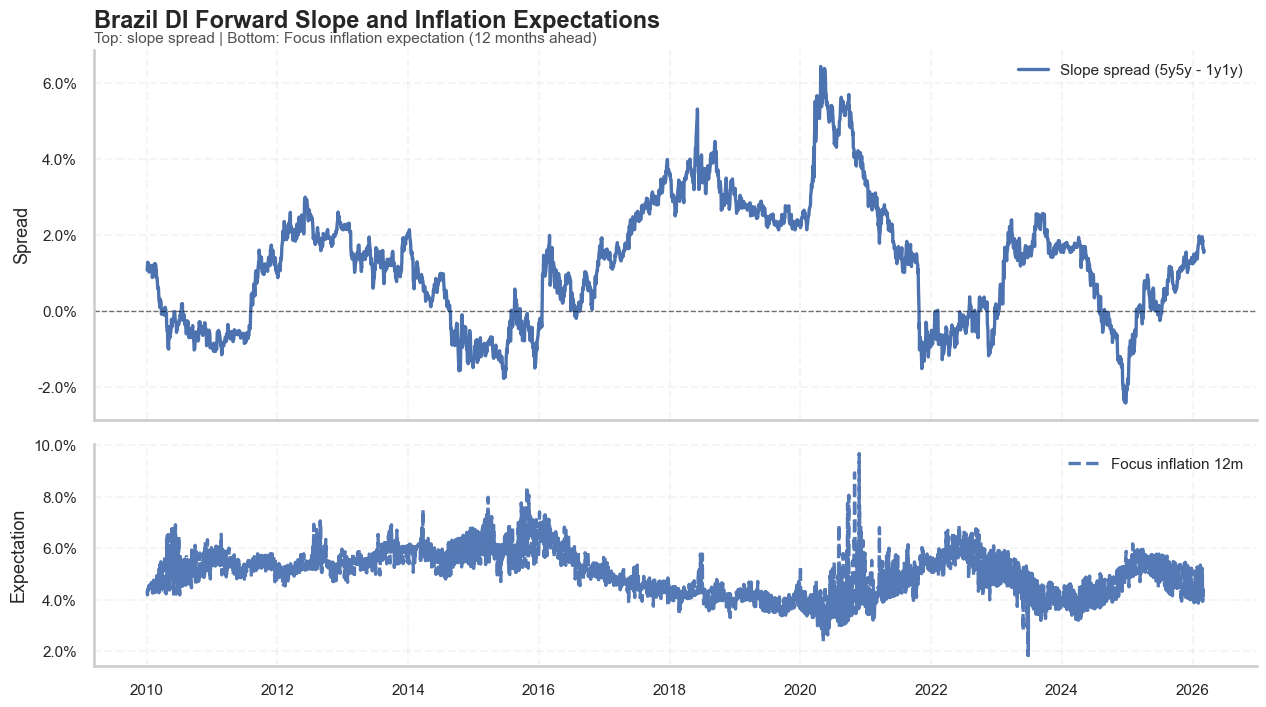

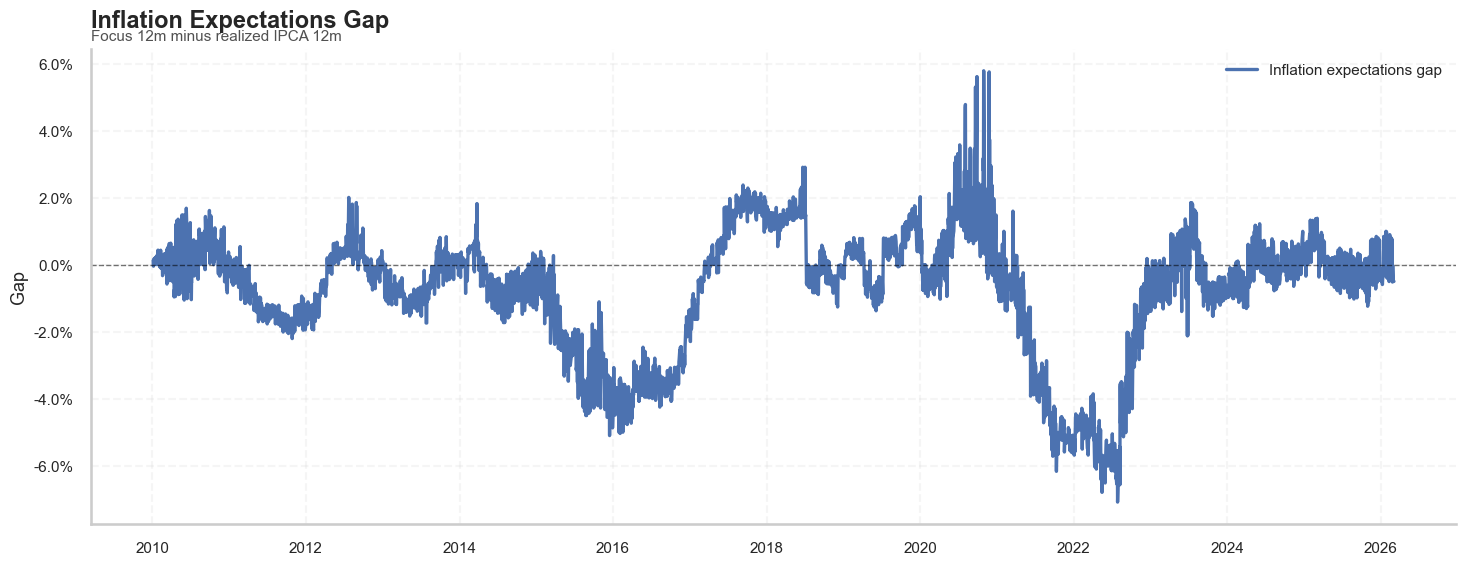

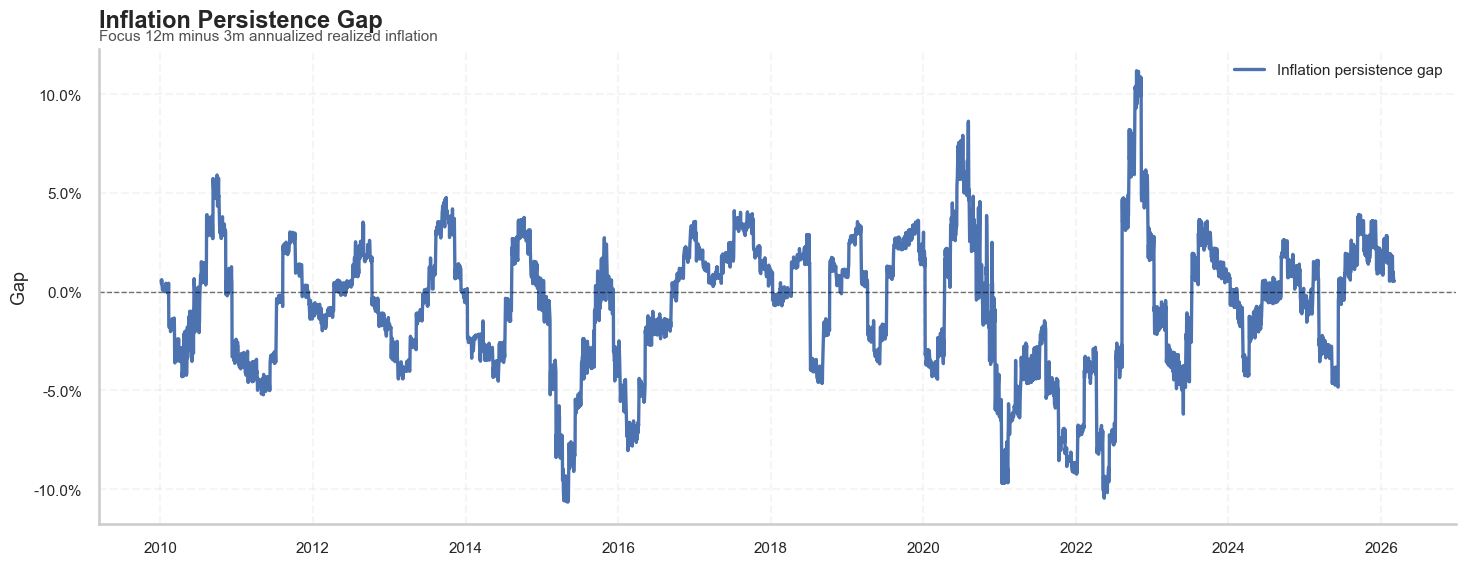


Saved files:
- c:\Projetos\estudo_curva\data_processed\macro\ipca_mom_sgs_433.csv
- c:\Projetos\estudo_curva\data_processed\macro\ibc_br_sa_sgs_24364.csv
- c:\Projetos\estudo_curva\data_processed\macro\focus_ipca_12m.csv
- c:\Projetos\estudo_curva\data_processed\curve_macro_merged.csv
- c:\Projetos\estudo_curva\data_processed\macro_data_dictionary.csv
- c:\Projetos\estudo_curva\figures\02_macro\fig_03_slope_and_focus12m_stacked.png
- c:\Projetos\estudo_curva\figures\02_macro\fig_04_inflation_expectations_gap.png
- c:\Projetos\estudo_curva\figures\02_macro\fig_05_inflation_persistence_gap.png


In [ ]:
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns


BASE_DIR = Path.cwd()

DATA_PROCESSED_DIR = BASE_DIR / "data_processed"
MACRO_DIR = DATA_PROCESSED_DIR / "macro"
FIG_DIR = BASE_DIR / "figures"
MACRO_FIG_DIR = FIG_DIR / "02_macro"

DATA_PROCESSED_DIR.mkdir(exist_ok=True)
MACRO_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
MACRO_FIG_DIR.mkdir(exist_ok=True)

CURVE_CSV = DATA_PROCESSED_DIR / "curve_forwards_252.csv"

curve_df = pd.read_csv(CURVE_CSV)
curve_df["date"] = pd.to_datetime(curve_df["date"], errors="coerce")
curve_df = curve_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

curve_start = curve_df["date"].min()
curve_end = curve_df["date"].max()

print("Curve sample:")
print(curve_start, "->", curve_end)
print(curve_df.head())

# ------------------------------------------------------------
# 2) Plot style
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "lines.linewidth": 2.4,
    "savefig.dpi": 300,
})

def pct_formatter(x, pos):
    return f"{x:.1f}%"

def setup_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("")
    sns.despine(ax=ax)

def add_subtitle(ax, subtitle: str):
    ax.text(
        0.0,
        1.02,
        subtitle,
        transform=ax.transAxes,
        fontsize=11,
        alpha=0.80
    )

# ------------------------------------------------------------
# 3) BCB SGS helper
# ------------------------------------------------------------
def fetch_bcb_sgs(series_code: int, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    """
    Download a time series from the BCB SGS API.

    Parameters
    ----------
    series_code : int
        SGS series code.
    start_date : pd.Timestamp
        Start date for download.
    end_date : pd.Timestamp
        End date for download.

    Returns
    -------
    pd.DataFrame
        Standardized dataframe with columns:
        - date
        - value
    """
    start_str = pd.Timestamp(start_date).strftime("%d/%m/%Y")
    end_str = pd.Timestamp(end_date).strftime("%d/%m/%Y")

    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{series_code}/dados"
        f"?formato=json&dataInicial={start_str}&dataFinal={end_str}"
    )

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    payload = response.json()

    df = pd.DataFrame(payload)

    if df.empty:
        return pd.DataFrame(columns=["date", "value"])

    df["date"] = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")
    df["value"] = pd.to_numeric(df["valor"].str.replace(",", ".", regex=False), errors="coerce")

    df = df[["date", "value"]].dropna().sort_values("date").reset_index(drop=True)
    return df

# ------------------------------------------------------------
# 4) BCB Expectations helper
# ------------------------------------------------------------
def fetch_focus_inflation_12m(start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    """
    Download BCB market expectations for inflation over the next 12 months.
    """
    url = (
        "https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/"
        "ExpectativasMercadoInflacao12Meses?$format=json&$top=100000"
    )

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    payload = response.json()

    if "value" not in payload:
        raise ValueError("Unexpected response format from BCB Expectations API.")

    df = pd.DataFrame(payload["value"])

    if df.empty:
        return pd.DataFrame(columns=["date", "value"])

    required_cols = {"Data", "Mediana"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(
            f"Missing required columns in BCB Expectations dataset: {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    df["date"] = pd.to_datetime(df["Data"], errors="coerce")
    df["value"] = pd.to_numeric(df["Mediana"], errors="coerce")

    df = df[["date", "value"]].dropna()

    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].copy()
    df = df.sort_values("date").drop_duplicates(subset="date", keep="last").reset_index(drop=True)

    return df

# ------------------------------------------------------------
# 5) Download macro series
# ------------------------------------------------------------
# A download buffer is used to make sure rolling calculations have enough history
download_start = curve_start - pd.DateOffset(years=2)
download_end = curve_end

# IPCA monthly inflation (% m/m) - SGS 433
ipca_mom = fetch_bcb_sgs(433, download_start, download_end)
ipca_mom = ipca_mom.rename(columns={"value": "ipca_mom"})
ipca_mom.to_csv(MACRO_DIR / "ipca_mom_sgs_433.csv", index=False)

# IBC-Br seasonally adjusted - SGS 24364
ibc_br_sa = fetch_bcb_sgs(24364, download_start, download_end)
ibc_br_sa = ibc_br_sa.rename(columns={"value": "ibc_br_sa"})
ibc_br_sa.to_csv(MACRO_DIR / "ibc_br_sa_sgs_24364.csv", index=False)

# Focus inflation for the next 12 months
focus_12m = fetch_focus_inflation_12m(download_start, download_end)
focus_12m = focus_12m.rename(columns={"value": "focus_ipca_12m"})
focus_12m.to_csv(MACRO_DIR / "focus_ipca_12m.csv", index=False)

print("\nIPCA monthly:")
print(ipca_mom.head())
print(ipca_mom.tail())

print("\nIBC-Br SA:")
print(ibc_br_sa.head())
print(ibc_br_sa.tail())

print("\nFocus 12m:")
print(focus_12m.head())
print(focus_12m.tail())

# ------------------------------------------------------------
# 6) Macro transformations
# ------------------------------------------------------------
# 6.1) Realized 12-month inflation
ipca_mom = ipca_mom.copy()
ipca_mom["ipca_mom_decimal"] = ipca_mom["ipca_mom"] / 100.0

ipca_mom["ipca_12m"] = (
    (1.0 + ipca_mom["ipca_mom_decimal"])
    .rolling(12)
    .apply(np.prod, raw=True) - 1.0
) * 100.0

# 6.2) 3-month annualized inflation proxy
ipca_mom["ipca_3m_saar"] = (
    (1.0 + ipca_mom["ipca_mom_decimal"])
    .rolling(3)
    .apply(np.prod, raw=True)
)
ipca_mom["ipca_3m_saar"] = (np.power(ipca_mom["ipca_3m_saar"], 4) - 1.0) * 100.0

# 6.3) Focus changes
focus_12m = focus_12m.copy()
focus_12m["focus_ipca_12m_chg_5d"] = focus_12m["focus_ipca_12m"].diff(5)
focus_12m["focus_ipca_12m_chg_21d"] = focus_12m["focus_ipca_12m"].diff(21)

# ------------------------------------------------------------
# 7) Release-date alignment to avoid look-ahead
# ------------------------------------------------------------
def assign_release_date_next_month(observation_date: pd.Timestamp, release_day_next_month: int) -> pd.Timestamp:
    """
    Assign a conservative release date in the following month.

    Example:
    - If a monthly observation belongs to January,
      and release_day_next_month = 10,
      it becomes available on approximately February 10.

    This is a pragmatic and conservative approximation for the case study.
    """
    obs = pd.Timestamp(observation_date)
    first_day_next_month = (obs + pd.offsets.MonthBegin(1)).normalize()
    release_date = first_day_next_month + pd.offsets.Day(release_day_next_month - 1)
    return release_date

# IPCA is conservatively assumed to become available on day 10 of the following month
ipca_release = ipca_mom[["date", "ipca_mom", "ipca_12m", "ipca_3m_saar"]].copy()
ipca_release["release_date"] = ipca_release["date"].apply(lambda d: assign_release_date_next_month(d, 10))
ipca_release = ipca_release.drop(columns=["date"]).sort_values("release_date").reset_index(drop=True)

# IBC-Br is conservatively assumed to become available on day 15 of the following month
ibc_release = ibc_br_sa.copy()
ibc_release["release_date"] = ibc_release["date"].apply(lambda d: assign_release_date_next_month(d, 15))
ibc_release = ibc_release.rename(columns={"ibc_br_sa": "ibc_br_sa_level"})
ibc_release = ibc_release.drop(columns=["date"]).sort_values("release_date").reset_index(drop=True)

# Focus is treated as available with a one-business-day operational lag
focus_daily = focus_12m.copy().sort_values("date").reset_index(drop=True)
focus_daily["available_date"] = focus_daily["date"] + pd.offsets.BDay(1)

# ------------------------------------------------------------
# 8) Merge macro data with the curve base
# ------------------------------------------------------------
merged = curve_df[[
    "date",
    "fwd_1y1y",
    "fwd_5y5y",
    "spread_5y5y_minus_1y1y",
]].copy()

merged = pd.merge_asof(
    merged.sort_values("date"),
    ipca_release.sort_values("release_date"),
    left_on="date",
    right_on="release_date",
    direction="backward",
)

merged = pd.merge_asof(
    merged.sort_values("date"),
    ibc_release.sort_values("release_date"),
    left_on="date",
    right_on="release_date",
    direction="backward",
)

merged = pd.merge_asof(
    merged.sort_values("date"),
    focus_daily[[
        "available_date",
        "focus_ipca_12m",
        "focus_ipca_12m_chg_5d",
        "focus_ipca_12m_chg_21d",
    ]].sort_values("available_date"),
    left_on="date",
    right_on="available_date",
    direction="backward",
)

# ------------------------------------------------------------
# 9) Candidate macro factors
# ------------------------------------------------------------
# Main candidate:
# expectation gap = Focus inflation 12m - realized inflation 12m
merged["inflation_expectations_gap"] = merged["focus_ipca_12m"] - merged["ipca_12m"]

# Alternative candidate:
# persistence gap = Focus inflation 12m - 3m annualized realized inflation
merged["inflation_persistence_gap"] = merged["focus_ipca_12m"] - merged["ipca_3m_saar"]

# Optional control variables
merged["spread_chg_5d"] = merged["spread_5y5y_minus_1y1y"].diff(5)
merged["spread_chg_21d"] = merged["spread_5y5y_minus_1y1y"].diff(21)
merged["ibc_br_sa_3m_change"] = merged["ibc_br_sa_level"].diff(3)

# ------------------------------------------------------------
# 10) Save merged dataset
# ------------------------------------------------------------
MERGED_CSV = DATA_PROCESSED_DIR / "curve_macro_merged.csv"
merged.to_csv(MERGED_CSV, index=False)

print("\nMerged dataset preview:")
print(merged.head())
print(merged.tail())

# ------------------------------------------------------------
# 11) Save a simple data dictionary
# ------------------------------------------------------------
data_dict = pd.DataFrame(
    {
        "variable": [
            "fwd_1y1y",
            "fwd_5y5y",
            "spread_5y5y_minus_1y1y",
            "ipca_mom",
            "ipca_12m",
            "ipca_3m_saar",
            "focus_ipca_12m",
            "inflation_expectations_gap",
            "inflation_persistence_gap",
            "ibc_br_sa_level",
        ],
        "description": [
            "1y1y forward rate from DI curve",
            "5y5y forward rate from DI curve",
            "Slope spread defined as 5y5y - 1y1y",
            "Monthly IPCA inflation (% m/m)",
            "Realized IPCA over 12 months (%)",
            "3-month annualized inflation proxy (%)",
            "Focus inflation expectation for the next 12 months (%)",
            "Focus 12m inflation minus realized IPCA 12m",
            "Focus 12m inflation minus 3m annualized inflation proxy",
            "IBC-Br seasonally adjusted level",
        ],
    }
)

data_dict.to_csv(DATA_PROCESSED_DIR / "macro_data_dictionary.csv", index=False)

# ------------------------------------------------------------
# 12) Figures for the report
# ------------------------------------------------------------

# Figure 3: slope spread and Focus inflation expectation
plot_df = merged[["date", "spread_5y5y_minus_1y1y", "focus_ipca_12m"]].dropna().sort_values("date")

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.2], "hspace": 0.08}
)

ax1.plot(
    plot_df["date"],
    plot_df["spread_5y5y_minus_1y1y"],
    label="Slope spread (5y5y - 1y1y)"
)
ax1.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax1.set_title("Brazil DI Forward Slope and Inflation Expectations", loc="left", pad=16, fontweight="bold")
add_subtitle(ax1, "Top: slope spread | Bottom: Focus inflation expectation (12 months ahead)")

ax1.set_ylabel("Spread")
ax1.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax1.legend(loc="upper right", frameon=False)

ax2.plot(
    plot_df["date"],
    plot_df["focus_ipca_12m"],
    linestyle="--",
    alpha=0.95,
    label="Focus inflation 12m"
)
ax2.set_ylabel("Expectation")
ax2.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax2.legend(loc="upper right", frameon=False)

setup_time_axis(ax2)

plt.tight_layout()
fig.savefig(MACRO_FIG_DIR / "fig_03_slope_and_focus12m_stacked.png", bbox_inches="tight")
fig.savefig(MACRO_FIG_DIR / "fig_03_slope_and_focus12m_stacked.pdf", bbox_inches="tight")
plt.show()

# Figure 4: inflation expectations gap
fig, ax = plt.subplots()

gap_df = merged[["date", "inflation_expectations_gap"]].dropna().sort_values("date")

ax.plot(
    gap_df["date"],
    gap_df["inflation_expectations_gap"],
    label="Inflation expectations gap"
)
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax.set_title("Inflation Expectations Gap", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Focus 12m minus realized IPCA 12m")

ax.set_ylabel("Gap")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(MACRO_FIG_DIR / "fig_04_inflation_expectations_gap.png", bbox_inches="tight")
fig.savefig(MACRO_FIG_DIR / "fig_04_inflation_expectations_gap.pdf", bbox_inches="tight")
plt.show()

# Figure 5: inflation persistence gap
fig, ax = plt.subplots()

pers_df = merged[["date", "inflation_persistence_gap"]].dropna().sort_values("date")

ax.plot(
    pers_df["date"],
    pers_df["inflation_persistence_gap"],
    label="Inflation persistence gap"
)
ax.axhline(0.0, color="black", linewidth=1.0, linestyle="--", alpha=0.55)

ax.set_title("Inflation Persistence Gap", loc="left", pad=16, fontweight="bold")
add_subtitle(ax, "Focus 12m minus 3m annualized realized inflation")

ax.set_ylabel("Gap")
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
setup_time_axis(ax)

ax.legend(loc="upper right", frameon=False)

plt.tight_layout()
fig.savefig(MACRO_FIG_DIR / "fig_05_inflation_persistence_gap.png", bbox_inches="tight")
fig.savefig(MACRO_FIG_DIR / "fig_05_inflation_persistence_gap.pdf", bbox_inches="tight")
plt.show()

print("\nSaved files:")
print(f"- {MACRO_DIR / 'ipca_mom_sgs_433.csv'}")
print(f"- {MACRO_DIR / 'ibc_br_sa_sgs_24364.csv'}")
print(f"- {MACRO_DIR / 'focus_ipca_12m.csv'}")
print(f"- {MERGED_CSV}")
print(f"- {DATA_PROCESSED_DIR / 'macro_data_dictionary.csv'}")
print(f"- {MACRO_FIG_DIR / 'fig_03_slope_and_focus12m_stacked.png'}")
print(f"- {MACRO_FIG_DIR / 'fig_04_inflation_expectations_gap.png'}")
print(f"- {MACRO_FIG_DIR / 'fig_05_inflation_persistence_gap.png'}")